In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler


Informações primárias para o projeto

In [47]:
df = pd.read_csv('amazon_sales_dataset.csv')
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [48]:
df.tail()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [49]:
df.columns.tolist()

['order_id',
 'order_date',
 'product_id',
 'product_category',
 'price',
 'discount_percent',
 'quantity_sold',
 'customer_region',
 'payment_method',
 'rating',
 'review_count',
 'discounted_price',
 'total_revenue']

In [50]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


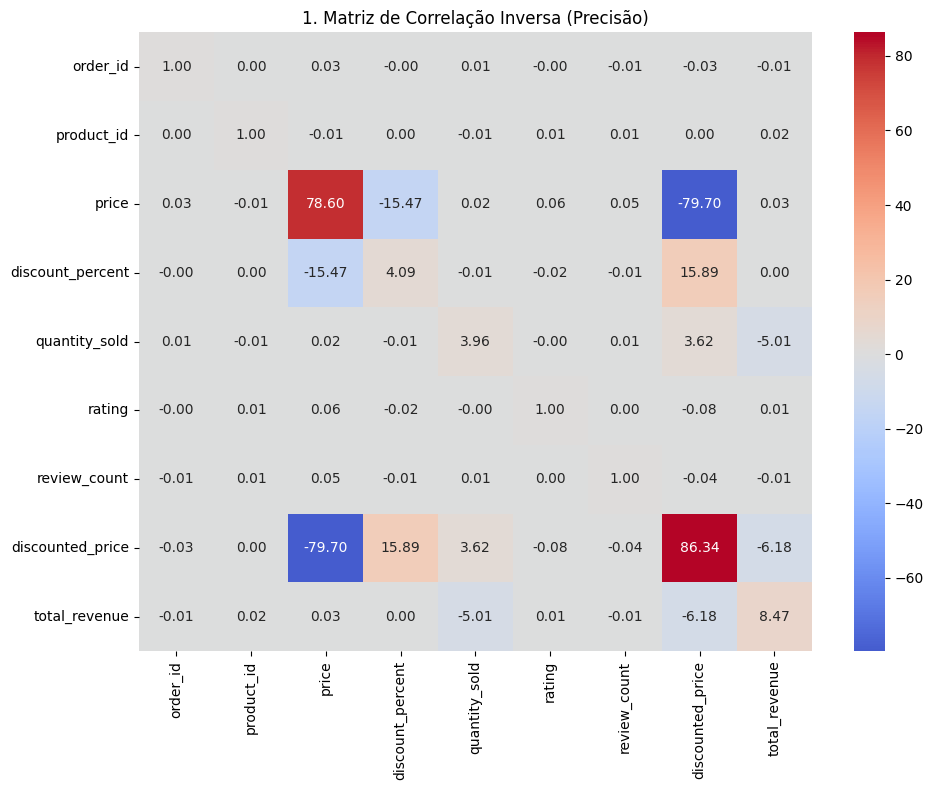

In [53]:
import numpy as np
import pandas as pd
plot_no = 1
df_num = df.select_dtypes(include='number')

corr_matrix = df_num.corr()

inv_corr = pd.DataFrame(
    np.linalg.inv(corr_matrix.values),
    index=corr_matrix.index,
    columns=corr_matrix.columns
)
plt.figure(figsize=(10, 8))
sns.heatmap(inv_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title(f'{plot_no}. Matriz de Correlação Inversa (Precisão)')
plt.tight_layout()
plt.show()
plot_no += 1

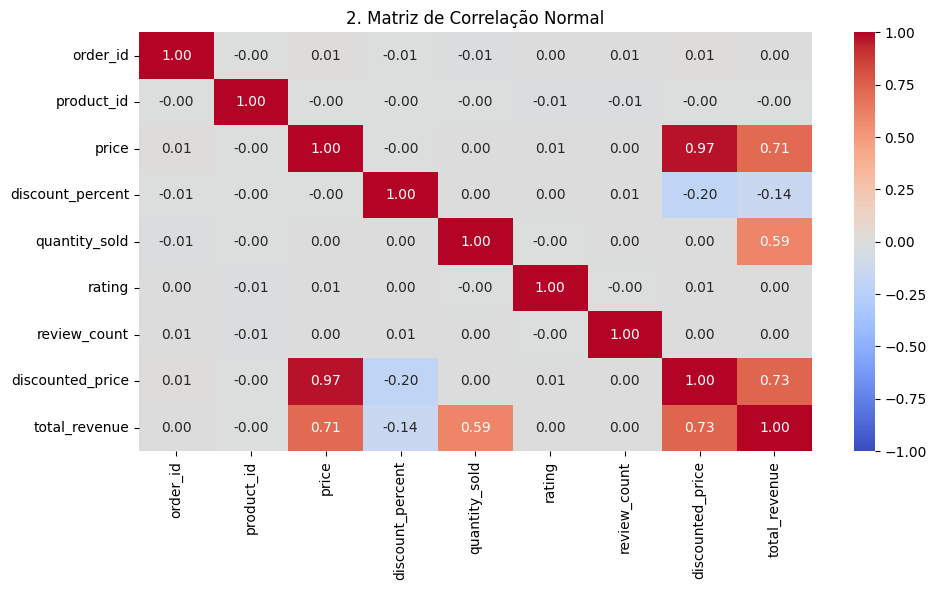

In [54]:


fig = plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title(f'{plot_no}. Matriz de Correlação Normal')
plt.tight_layout()
plt.show()
plot_no += 1

Treinamento

In [55]:
cluster_df = df.groupby('customer_region').agg(
    total_revenue=('total_revenue', 'sum'),
    avg_discount=('discount_percent', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_price=('price', 'mean'),
    quantity_sold=('quantity_sold', 'sum'),
    avg_review_count=('review_count', 'mean')
).reset_index()

# One-hot encoding do método de pagamento preferido
payment_pref = df.groupby(['customer_region', 'payment_method'])['order_id'].count().unstack(fill_value=0)
payment_pref = payment_pref.div(payment_pref.sum(axis=1), axis=0)  # proporção

cluster_df = cluster_df.merge(payment_pref, on='customer_region')

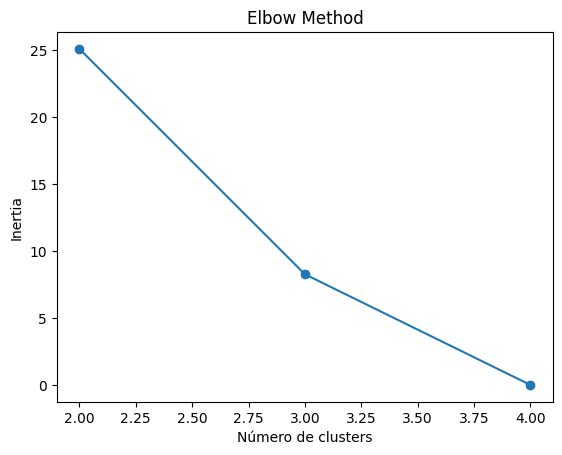

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
features = cluster_df.drop(columns='customer_region')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
inertias = []
n_regions = df['customer_region'].nunique()
K = range(2, n_regions + 1)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

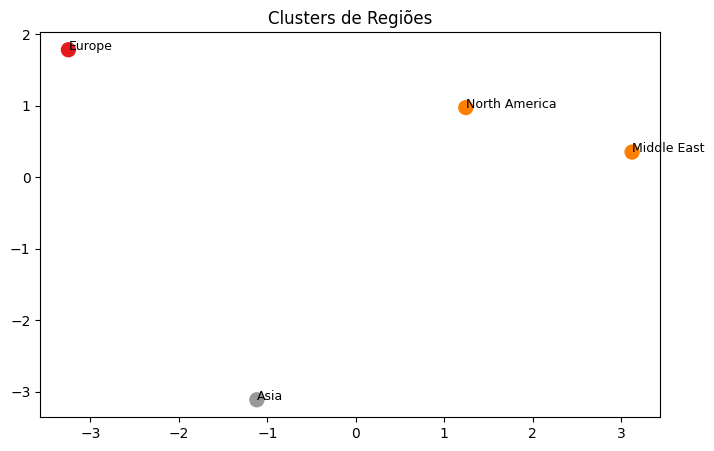

In [58]:
km = KMeans(n_clusters=3, random_state=42)  # ajuste após o elbow
cluster_df['cluster'] = km.fit_predict(X_scaled)

# Visualizar com PCA (reduzir para 2D)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=cluster_df['cluster'], cmap='Set1', s=100)
for i, region in enumerate(cluster_df['customer_region']):
    plt.annotate(region, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title('Clusters de Regiões')
plt.show()

In [ ]:
cluster_df.groupby('cluster').mean(numeric_only=True).T.style.format('{:.2f}')

cluster,0,1,2
total_revenue,8112311.57,8289531.17,8175199.83
avg_discount,13.35,13.26,13.48
avg_rating,2.97,3.01,3.00
avg_price,251.62,253.11,252.18
quantity_sold,37302.00,37614.00,37440.00
avg_review_count,249.06,250.06,248.13
Cash on Delivery,0.19,0.20,0.20
Credit Card,0.20,0.20,0.20
Debit Card,0.20,0.20,0.20
UPI,0.20,0.20,0.21


: 